In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbs

In [3]:
df = pd.read_csv('../data/03_Online_Retail.csv', encoding="ISO-8859-1")

print("Shape:", df.shape)
df.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
InvoiceNo           0
StockCode           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

In [6]:
df[df["Quantity"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom


In [7]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

In [8]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

/var/folders/qw/d10v9ky119106g6z7cd3jrsc0000gn/T/ipykernel_66828/2755723760.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(


In [9]:

df = df.dropna(subset=["InvoiceDate"])

df["Date"] = df["InvoiceDate"].dt.date

df["Date"].min(), df["Date"].max()

(datetime.date(2010, 12, 1), datetime.date(2011, 12, 9))

In [10]:
daily_demand = (
    df
    .groupby(["Date", "Country"])["Quantity"]
    .sum()
    .reset_index()
    .rename(columns={"Quantity": "Demand"})
)

daily_demand.head()

,Date,Country,Demand
0,2010-12-01,Australia,107
1,2010-12-01,EIRE,243
2,2010-12-01,France,449
3,2010-12-01,Germany,157
4,2010-12-01,Netherlands,97


In [11]:
daily_demand["Date"] = pd.to_datetime(daily_demand["Date"])

daily_demand["year"] = daily_demand["Date"].dt.year
daily_demand["month"] = daily_demand["Date"].dt.month
daily_demand["day_of_week"] = daily_demand["Date"].dt.dayofweek


In [12]:
uk_demand = daily_demand[
    daily_demand["Country"] == "United Kingdom"
].sort_values("Date")

uk_demand.head()

,Date,Country,Demand,year,month,day_of_week
6,2010-12-01,United Kingdom,24014,2010,12,2
9,2010-12-02,United Kingdom,31175,2010,12,3
19,2010-12-03,United Kingdom,11808,2010,12,4
24,2010-12-05,United Kingdom,13660,2010,12,6
28,2010-12-06,United Kingdom,21039,2010,12,0


In [13]:
uk_demand["lag_1"] = uk_demand["Demand"].shift(1)
uk_demand["lag_7"] = uk_demand["Demand"].shift(7)
uk_demand["lag_14"] = uk_demand["Demand"].shift(14)

uk_demand["rolling_7_mean"] = (
    uk_demand["Demand"].shift(1).rolling(7).mean()
)

uk_demand["rolling_14_mean"] = (
    uk_demand["Demand"].shift(1).rolling(14).mean()
)
uk_demand = uk_demand.dropna()


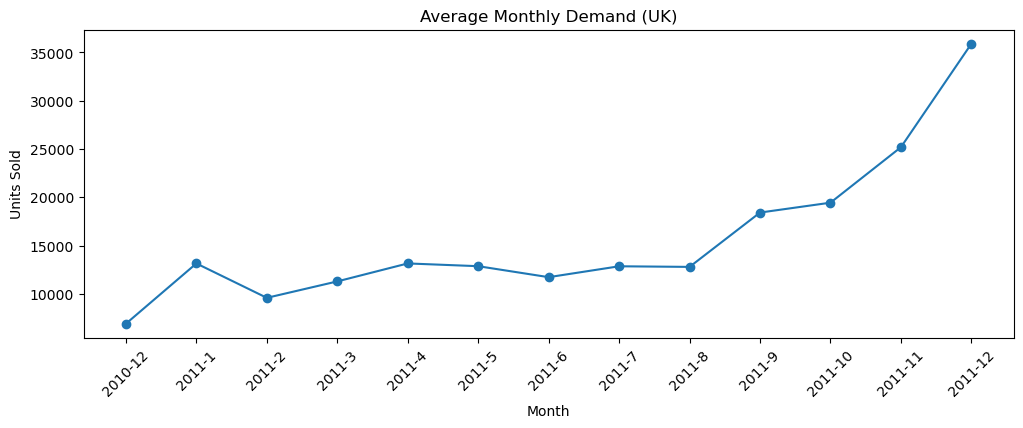

In [17]:
monthly_demand = (
    uk_demand
    .groupby(["year", "month"])["Demand"]
    .mean()
    .reset_index()
)

monthly_demand["YearMonth"] = (
    monthly_demand["year"].astype(str)
    + "-"
    + monthly_demand["month"].astype(str)
)

plt.figure(figsize=(12, 4))
plt.plot(
    monthly_demand["YearMonth"],
    monthly_demand["Demand"],
    marker="o"
)
plt.xticks(rotation=45)
plt.title("Average Monthly Demand (UK)")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

In [19]:
selected_countries = [
    "United Kingdom",
    "France",
    "Germany",
    "Netherlands"
]

multi_country = daily_demand[
    daily_demand["Country"].isin(selected_countries)
].sort_values("Date")

multi_country.head()

,Date,Country,Demand,year,month,day_of_week
2,2010-12-01,France,449,2010,12,2
3,2010-12-01,Germany,157,2010,12,2
4,2010-12-01,Netherlands,97,2010,12,2
6,2010-12-01,United Kingdom,24014,2010,12,2
8,2010-12-02,Germany,148,2010,12,3


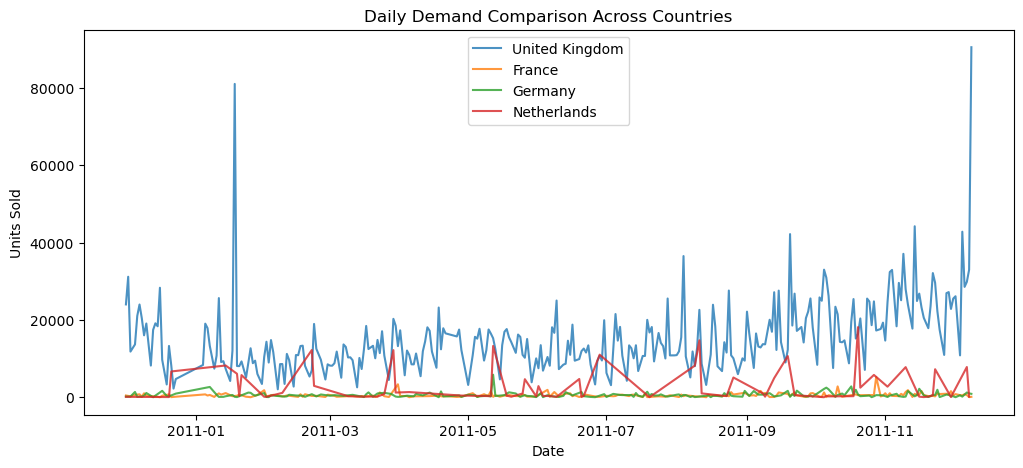

In [20]:
plt.figure(figsize=(12, 5))

for country in selected_countries:
    country_df = multi_country[
        multi_country["Country"] == country
    ]

    plt.plot(
        country_df["Date"],
        country_df["Demand"],
        label=country,
        alpha=0.8
    )

plt.title("Daily Demand Comparison Across Countries")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.show()